# Hasse Search Space Estimation

## Setup

In [1]:
import json
import numpy as np
import os
from pprint import pprint
from statistics import mean, stdev
from typing import List, Dict

In [2]:
%pip install matplotlib
import matplotlib.pyplot as plt

You should consider upgrading via the '/Users/christophstein/Documents/jku/crossover_evaluation/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pandas
import pandas as pd

You should consider upgrading via the '/Users/christophstein/Documents/jku/crossover_evaluation/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install tqdm
from tqdm import tqdm

You should consider upgrading via the '/Users/christophstein/Documents/jku/crossover_evaluation/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Util functions

In [5]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

In [6]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

In [7]:
from dataclasses import dataclass

@dataclass
class Experiment:
    qubit_num: int
    gate_count: int
    gate_set: str
    population_size: int
    max_generations: int
    mutation_prob: float
    crossover_prob: float
    crossover: str
    mutation: str

    source_paths: List[str]
    seeds: List[int]

    label: str

    fitness_scores: pd.DataFrame
    fitness_scores_per_seed: List[pd.DataFrame]

    def __hash__(self) -> str:
        key = f"{self.qubit_num}q{self.gate_count}g{self.gate_set}gs"
        key += f"{self.population_size}p{self.max_generations}mg{self.mutation_prob}mp"
        key += f"{self.crossover_prob}cp{self.crossover}c{self.mutation}m"
        return hash(key)
    
    def __eq__(self, value: "Experiment"):
        return self.__hash__() == value.__hash__()


In [8]:
# Filter experiments

def filter_experiments(experiments: List[Experiment], target_qubit_nums: List[int] = None, target_gate_counts: List[int] = None, sort_by: str = "qubit_num") -> List:
    assert target_qubit_nums is not None or target_gate_counts is not None

    filtered_experiments = []
    for experiment in experiments:

        if target_qubit_nums is None:
            if experiment.gate_count in target_gate_counts:
                filtered_experiments.append(experiment)
        elif target_gate_counts is None:
            if experiment.qubit_num in target_qubit_nums:
                filtered_experiments.append(experiment)
        elif experiment.gate_count in target_gate_counts and experiment.qubit_num in target_qubit_nums: 
            filtered_experiments.append(experiment)

    filtered_experiments.sort(key=lambda item: item["config"][sort_by])
    return filtered_experiments

In [9]:
def merge_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    lengths = [len(df) for df in dfs]
    assert len(set(lengths)) == 1, "Received dataframes with different lengths."

    total_df = pd.concat(dfs)

    avg_best = total_df.groupby("generation")["best_fitness"].mean()
    std_best = total_df.groupby("generation")["best_fitness"].std()
    avg_mean = total_df.groupby("generation")["mean_fitness"].mean()
    std_mean = total_df.groupby("generation")["mean_fitness"].std()

    merged_df = pd.concat([avg_best, std_best, avg_mean, std_mean], keys=[
                          "avg_best", "std_best", "avg_mean", "std_mean"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

## Load Data

In [10]:
def load_experiments(results_dir: str = "results", prefix: str = None) -> List[Experiment]:
    experiments: Dict[str, Experiment] = {}

    for file_name in os.listdir(results_dir):
        if not file_name.endswith("_config.json"):
            continue

        if prefix is not None and not file_name.startswith(prefix):
            continue

        config_path = f"{results_dir}/{file_name}"
        config = load_json(config_path)

        fitness_path = f"{results_dir}/{file_name.replace('_config.json', '_fitness.csv')}"
        experiment_fitness = pd.read_csv(fitness_path, delimiter=";")
        for column in experiment_fitness.columns:
            experiment_fitness = experiment_fitness.rename(columns={
                column: column.strip().replace(" ", "_")
            })

        label = "None"
        if config["mutation_prob"] == 1.0:
            label = "Random Search"
        elif config["crossover"] == "One Point Crossover":
            label = "One Point Crossover"
        elif config["crossover"] == "Headless Chicken(One Point Crossover)":
            label = "Pseudo One Point"
        else:
            raise NotImplementedError(f"Unknown search strategy for experiment at {file_name}")

        experiment = Experiment(
            qubit_num=config["qubit_num"],
            gate_count=config["gate_count"],
            gate_set=config["gate_set"],
            population_size=config["population_size"],
            max_generations=config["max_generations"],
            mutation_prob=config["mutation_prob"],
            crossover_prob=config["crossover_prob"],
            crossover=config["crossover"],
            mutation=config["mutation"],

            label=label,

            source_paths=[
                config_path
            ],
            seeds=[
                config["seed"]
            ],

            fitness_scores=None,
            fitness_scores_per_seed=[experiment_fitness]
        )

        if experiment in experiments:
            experiments[experiment].source_paths.append(
                experiment.source_paths[0])
            experiments[experiment].seeds.append(experiment.seeds[0])
            experiments[experiment].fitness_scores_per_seed.append(
                experiment.fitness_scores_per_seed[0])
        else:
            experiments[experiment] = experiment

    experiments: List[Experiment] = list(experiments.values())
    for experiment in experiments:
        fitness_dfs = experiment.fitness_scores_per_seed
        lengths = [len(df) for df in fitness_dfs]

        entries_to_pop = [
            i for i, length in enumerate(lengths) if length < max(lengths)
        ]

        for entry_to_pop in reversed(entries_to_pop):
            print(
                f"Excluding fitness of {experiment.source_paths[entry_to_pop]} due to length mismatch.")

            experiment.source_paths.pop(entry_to_pop)
            experiment.seeds.pop(entry_to_pop)
            experiment.fitness_scores_per_seed.pop(entry_to_pop)

        experiment.fitness_scores = merge_dfs(
            experiment.fitness_scores_per_seed)

    return experiments




## Visualization Functions

In [11]:
def plot_fitness_per_generation(experiments: List[Experiment], measure: str, target_path: str, plot_ci: bool = False) -> None:
    if measure not in ["best", "mean"]:
        raise NotImplementedError(
            f"Measure '{measure}' has not been implemented.")

    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.fitness_scores

        if measure == "best":
            ax.plot(df["generation"], df["avg_best"], label=experiment.label, linewidth=1)

            if plot_ci:
                lower_bound = df["avg_best"] - df["std_best"]
                upper_bound = df["avg_best"] + df["std_best"]
                ax.fill_between(
                    df["generation"], lower_bound, upper_bound, alpha=0.3
                )
        else:
            ax.plot(df["generation"], df["avg_mean"], label=experiment.label, linewidth=1)

            if plot_ci:
                lower_bound = df["avg_mean"] - df["std_mean"]
                upper_bound = df["avg_mean"] + df["std_mean"]
                ax.fill_between(
                    df["generation"], lower_bound, upper_bound, alpha=0.3
                )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    if measure == "best":
        ax.set_ylabel("avg. best fitness")
    else:
        ax.set_ylabel("avg. mean fitness")

    plt.grid()
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.savefig(target_path, bbox_inches='tight')
    plt.show()
    plt.clf()

## Results


In [12]:
experiments = load_experiments(prefix=None)
print(f"Number of synthesis experiments: {len(experiments)}")

assert len(experiments) <= 3, "Current evaluation only supports visualization of a single experiment configuration."

Excluding fitness of results/3q10g1.0mp0.0cp_one point crossover_1s_config.json due to length mismatch.
Number of synthesis experiments: 3


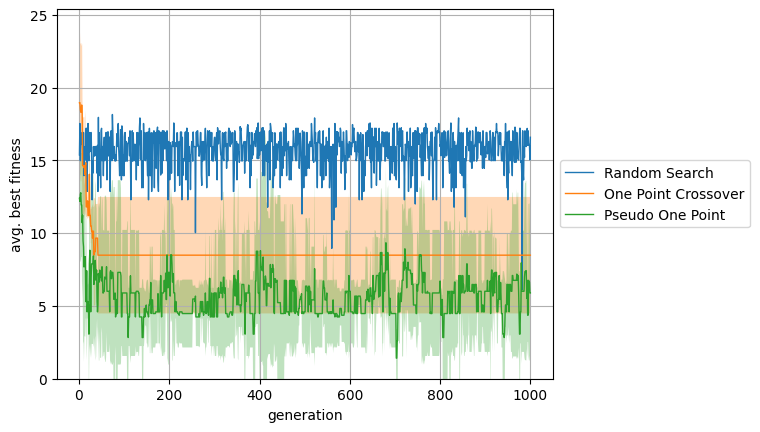

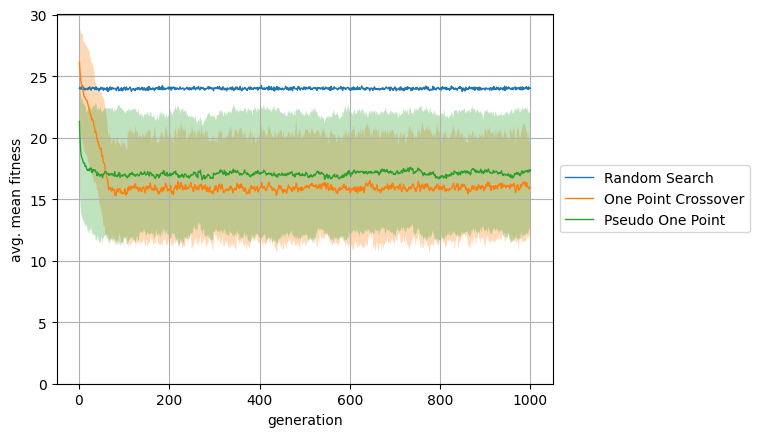

<Figure size 640x480 with 0 Axes>

In [13]:
# Visualize fitness functions & sanity check for deviations between different caches.

plot_fitness_per_generation(experiments, measure="best", target_path="results/best_fitness.png", plot_ci=True)
plot_fitness_per_generation(experiments, measure="mean", target_path="results/mean_fitness.png", plot_ci=True)
